# Day 21-22: SHAP 模型解释
Summary Plot → Dependence Plot → Waterfall Plot → 特征重要性对比

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import joblib
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

# 加载最终模型
try:
    model = joblib.load('../models/day18_xgb_final.pkl')
    print("✓ 加载 Day 18 最终模型")
except:
    model = joblib.load('../models/day17_xgb_tuned_learning.pkl')
    print("✓ 加载 Day 17 模型")

print(f"测试集 R²: {model.score(X_test, y_test):.4f}")

训练集: (3811, 135), 测试集: (953, 135)
✓ 加载 Day 18 最终模型
测试集 R²: 0.6896


## Summary Plot 
横轴 SHAP 值（正=推高预测，负=拉低预测），颜色=特征值大小，每行一个特征

创建 SHAP 解释器...
计算 953 个样本的 SHAP 值...
SHAP 值形状: (953, 135)  ← (样本数, 特征数)


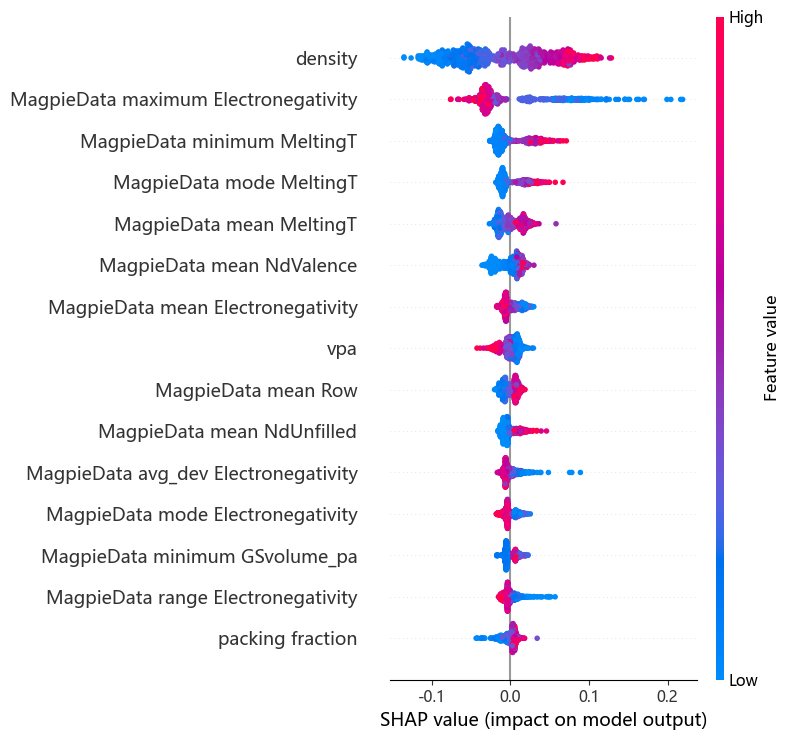

✓ Summary Plot 已保存


In [23]:
print("创建 SHAP 解释器...")
explainer = shap.TreeExplainer(model)


X_explain = X_test
print(f"计算 {X_explain.shape[0]} 个样本的 SHAP 值...")
shap_values = explainer.shap_values(X_explain)
print(f"SHAP 值形状: {shap_values.shape}  ← (样本数, 特征数)")

# Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_explain, show=False, max_display=15)
plt.tight_layout()
plt.savefig('../figures/day21_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Summary Plot 已保存")

##  Dependence Plot — 单个特征的详细影响
看一个特征在不同取值下对预测的贡献（找非线性关系）

Top 1 特征: density (SHAP importance=0.0522)


<Figure size 640x480 with 0 Axes>

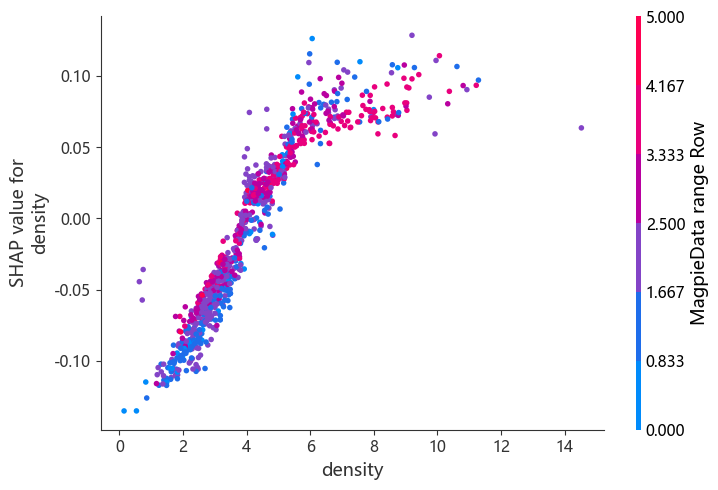

✓ Dependence Plot 已保存


In [24]:
# 计算全局 SHAP 重要性，找 Top 1 特征
shap_importance = np.abs(shap_values).mean(axis=0)
top_idx = np.argmax(shap_importance)
top_feature = X.columns[top_idx]
print(f"Top 1 特征: {top_feature} (SHAP importance={shap_importance[top_idx]:.4f})")

# Dependence Plot
plt.figure()
shap.dependence_plot(
    top_idx, shap_values, X_explain,
    show=False
)
plt.tight_layout()
plt.savefig(f'../figures/day21_shap_dependence_{top_feature}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Dependence Plot 已保存")

##  Waterfall Plot — 解释单个样本
为什么这个样本的预测值是 X？从基准值出发，每个特征往上推或往下拉

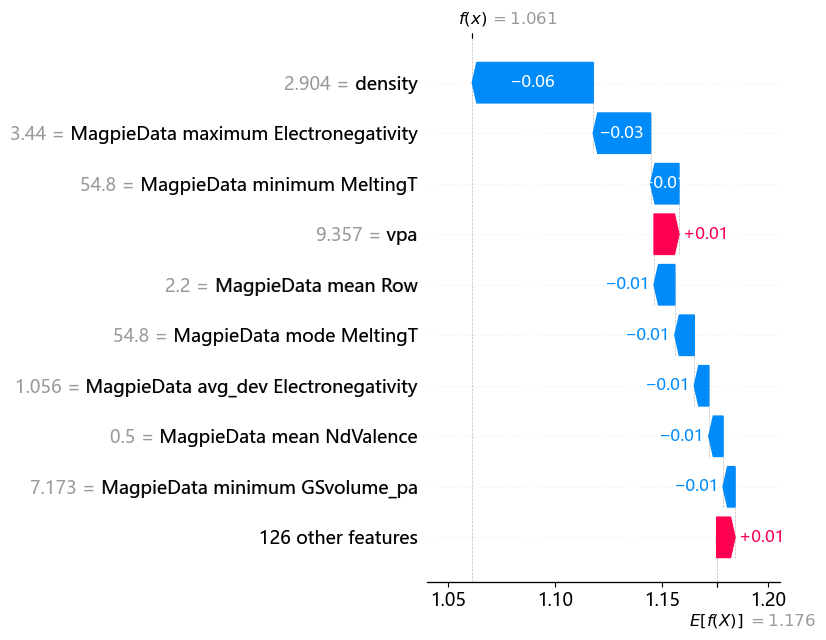

✓ Waterfall Plot 已保存

解读: 基准值 E[f(X)]=1.1757
      最终预测 f(x)=1.0613


In [ ]:
sample_idx = 0  # 解释第 1 个测试样本

plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_explain.iloc[sample_idx],
        feature_names=X.columns.tolist()
    ),
    show=False,
    max_display=10  # 只显示 Top 10 特征
)
plt.tight_layout()
plt.savefig('../figures/day21_shap_waterfall_sample0.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Waterfall Plot 已保存")
print(f"\n解读: 基准值 E[f(X)]={explainer.expected_value:.4f}")
print(f"      最终预测 f(x)={explainer.expected_value + shap_values[sample_idx].sum():.4f}")

##  四种特征重要性对比
SHAP vs XGBoost 内置 vs 排列重要性 vs 决策树

SHAP Top 15 特征在两种方法中的排名对比:
                             feature  shap_rank  xgb_rank  rank_diff
                             density          0         8         -8
MagpieData maximum Electronegativity          1         0          1
         MagpieData minimum MeltingT          2         2          0
            MagpieData mode MeltingT          3         3          0
            MagpieData mean MeltingT          4        26        -22
           MagpieData mean NdValence          5        23        -18
   MagpieData mean Electronegativity          6        62        -56
                                 vpa          7       103        -96
                 MagpieData mean Row          8        18        -10
          MagpieData mean NdUnfilled          9        38        -29
MagpieData avg_dev Electronegativity         10        54        -44
   MagpieData mode Electronegativity         11        20         -9
      MagpieData minimum GSvolume_pa         12         7          5
  Magpi

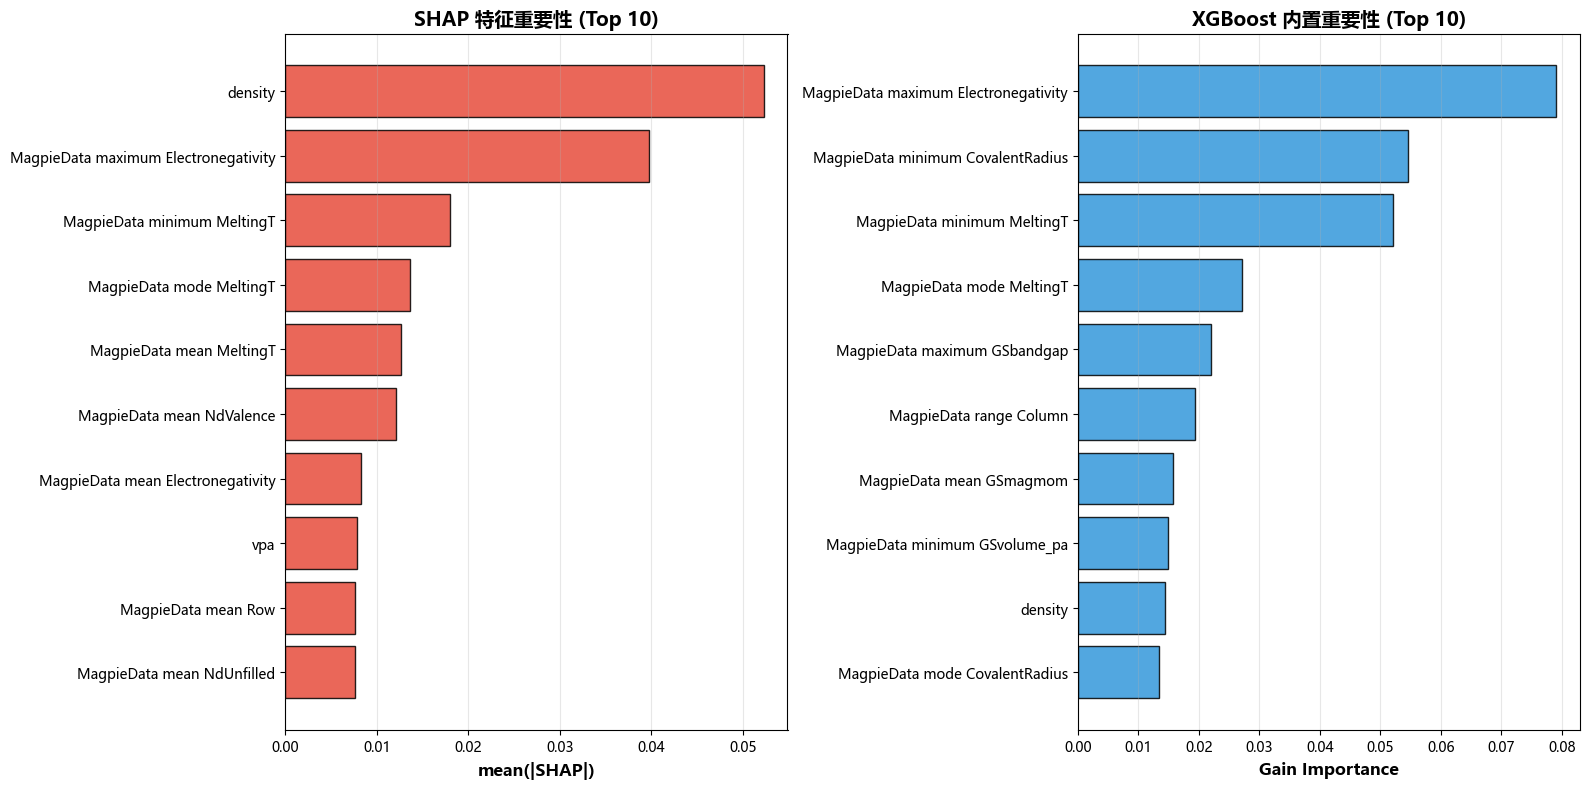

✓ 重要性对比图已保存


In [26]:
# 1. SHAP 重要性（全局）
shap_imp_df = pd.DataFrame({
    'feature': X.columns,
    'SHAP': shap_importance
}).sort_values('SHAP', ascending=False).reset_index(drop=True)
shap_imp_df.index.name = 'shap_rank'

# 2. XGBoost 内置重要性
xgb_imp = pd.DataFrame({
    'feature': X.columns,
    'XGBoost': model.feature_importances_
}).sort_values('XGBoost', ascending=False).reset_index(drop=True)
xgb_imp.index.name = 'xgb_rank'

# 3. 对比：给每个特征标注在两种方法中的排名
# 取 SHAP Top 15 的特征，查它们在 XGBoost 里的排名
shap_top15 = shap_imp_df.head(15).copy()
shap_top15['shap_rank'] = shap_top15.index          # SHAP 里的排名 (0-based)
shap_top15['xgb_rank'] = shap_top15['feature'].apply(
    lambda f: xgb_imp[xgb_imp['feature'] == f].index[0]
    if f in xgb_imp['feature'].values else -1
)
shap_top15['rank_diff'] = shap_top15['shap_rank'] - shap_top15['xgb_rank']

print("SHAP Top 15 特征在两种方法中的排名对比:")
print(shap_top15[['feature', 'shap_rank', 'xgb_rank', 'rank_diff']].to_string(index=False))

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 左：SHAP
ax1 = axes[0]
top10 = shap_imp_df.head(10).iloc[::-1]
ax1.barh(range(10), top10['SHAP'], color='#e74c3c', alpha=0.85, edgecolor='black')
ax1.set_yticks(range(10))
ax1.set_yticklabels(top10['feature'])
ax1.set_xlabel('mean(|SHAP|)', fontsize=12, fontweight='bold')
ax1.set_title('SHAP 特征重要性 (Top 10)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 右：XGBoost 内置
ax2 = axes[1]
top10_xgb = xgb_imp.head(10).iloc[::-1]
ax2.barh(range(10), top10_xgb['XGBoost'], color='#3498db', alpha=0.85, edgecolor='black')
ax2.set_yticks(range(10))
ax2.set_yticklabels(top10_xgb['feature'])
ax2.set_xlabel('Gain Importance', fontsize=12, fontweight='bold')
ax2.set_title('XGBoost 内置重要性 (Top 10)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../figures/day21_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 重要性对比图已保存")

In [27]:
# 保存 SHAP 结果
import json

def to_python(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list): return [to_python(v) for v in obj]
    return obj

shap_summary = {
    'top10_shap_features': to_python(shap_imp_df.head(10).to_dict('records')),
    'top10_xgb_features': to_python(xgb_imp.head(10).to_dict('records')),
    'model_test_r2': float(model.score(X_test, y_test))
}

with open('../models/day21_shap_results.json', 'w') as f:
    json.dump(shap_summary, f, indent=2)
print("✓ SHAP 结果已保存")

print("\n" + "=" * 60)
print("Day 21-22 总结")
print("=" * 60)
print(f"\nSHAP 核心发现:")
print(f"  Top 1 特征: {top_feature}")
print(f"  SHAP Top 3: {shap_imp_df['feature'].head(3).tolist()}")
print(f"  XGBoost Top 3: {xgb_imp['feature'].head(3).tolist()}")
print(f"\nSHAP 回答的问题:")
print(f"  1. 哪些特征最重要？ → Summary Plot")
print(f"  2. 特征怎么影响预测？ → Dependence Plot")
print(f"  3. 为什么这个样本预测是 X？ → Waterfall Plot")
print("=" * 60)

✓ SHAP 结果已保存

Day 21-22 总结

SHAP 核心发现:
  Top 1 特征: density
  SHAP Top 3: ['density', 'MagpieData maximum Electronegativity', 'MagpieData minimum MeltingT']
  XGBoost Top 3: ['MagpieData maximum Electronegativity', 'MagpieData minimum CovalentRadius', 'MagpieData minimum MeltingT']

SHAP 回答的问题:
  1. 哪些特征最重要？ → Summary Plot
  2. 特征怎么影响预测？ → Dependence Plot
  3. 为什么这个样本预测是 X？ → Waterfall Plot
